<a href="https://colab.research.google.com/github/italomarcony/desafio_lh_nautical/blob/main/lh_nautical_desafio_indicium.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LH Nautical – Desafio Lighthouse (Indicium AI)

Italo Marcony Souza Silva

E-mail: italomarcony130@gmail.com

Caso não carregue algum gráfico ou ocorra um erro acesse o notebook no google colab : https://colab.research.google.com/drive/1GEHc9NpfisJJbUjJr-OrApCw0l8UEm3T?usp=sharing

Notebook de consolidação das análises (EDA, schema, carregamento, vendas, clientes, previsão de demanda e recomendação).

## 0. Setup e leitura dos dados


In [ ]:
# 0. Setup – importar bibliotecas básicas

import pandas as pd
import numpy as np

# (se precisar depois)
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
pd.set_option("display.max_rows", 10)
pd.set_option("display.max_columns", 50)
sns.set(style="whitegrid")

In [ ]:
# Leitura dos principais CSVs

orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
products = pd.read_csv("products.csv")
product_variants = pd.read_csv("product_variants.csv")
customers = pd.read_csv("customers.csv")
categories = pd.read_csv("categories.csv")

print("Tabelas carregadas:")
for name, df in [
    ("orders", orders),
    ("order_items", order_items),
    ("products", products),
    ("product_variants", product_variants),
    ("customers", customers),
    ("categories", categories),
]:
    print(f"{name}: {df.shape[0]} linhas, {df.shape[1]} colunas")

Tabelas carregadas:
orders: 48998 linhas, 13 colunas
order_items: 147320 linhas, 8 colunas
products: 500 linhas, 10 colunas
product_variants: 1009 linhas, 12 colunas
customers: 2000 linhas, 11 colunas
categories: 14 linhas, 7 colunas


## 1. EDA inicial – tabela `orders`


### Objetivo

Explorar a tabela `orders` para entender:
- volume de linhas,
- intervalo temporal,
- distribuição básica da coluna `total`,
- presença de nulos em colunas-chave.

In [ ]:
# EDA básica da tabela orders

print("Head de orders:")
display(orders.head())

print("\nTipos de dados:")
print(orders.dtypes)

print("\nResumo estatístico da coluna total:")
print(orders["total"].describe())

print("\nIntervalo de datas em created_at:")
orders["created_at"] = pd.to_datetime(orders["created_at"])
print("Data mínima:", orders["created_at"].min())
print("Data máxima:", orders["created_at"].max())

print("\nNulos nas colunas-chave (created_at, total):")
print(orders[["created_at", "total"]].isna().sum())

Head de orders:


,id,order_number,channel,customer_id,salesperson_id,location_id,status,subtotal,discount_amount,total,placed_at,created_at,updated_at
0,1,SO-000001,ecommerce,1136,NaN,1,paid,323.34,35.57,287.77,2022-09-06 05:37:37,2022-09-06 05:37:37,2022-09-06 05:37:37
1,2,SO-000002,ecommerce,618,9.0,4,paid,53199.05,0.00,53199.05,2023-02-03 04:36:21,2023-02-03 04:36:21,2023-02-03 04:36:21
2,3,SO-000003,pos,227,10.0,4,confirmed,17157.39,0.00,17157.39,2024-12-30 07:15:17,2024-12-30 07:15:17,2024-12-30 07:15:17
3,4,SO-000004,ecommerce,1123,NaN,3,paid,11095.62,665.74,10429.88,2024-03-12 20:39:36,2024-03-12 20:39:36,2024-03-12 20:39:36
4,5,SO-000005,ecommerce,426,9.0,2,confirmed,32842.03,0.00,32842.03,2020-03-27 13:52:12,2020-03-27 13:52:12,2020-03-27 13:52:12



Tipos de dados:
id                   int64
order_number        object
channel             object
customer_id          int64
salesperson_id     float64
                    ...   
discount_amount    float64
total              float64
placed_at           object
created_at          object
updated_at          object
Length: 13, dtype: object

Resumo estatístico da coluna total:
count     48998.000000
mean      28704.992077
std       19425.636818
min          32.620000
25%       13171.235000
50%       25917.840000
75%       40941.882500
max      127262.020000
Name: total, dtype: float64

Intervalo de datas em created_at:
Data mínima: 2020-01-01 01:19:28
Data máxima: 2026-12-31 23:43:09

Nulos nas colunas-chave (created_at, total):
created_at    0
total         0
dtype: int64


**Resumo:**  
- `orders` tem 48.998 registros, cobrindo o período de 2020-01-01 a 2026-12-31.  
- `total` varia de aproximadamente R$32,62  a  R$127.262,02, com média em torno de R$ 28.704,99.  
- Não há nulos em `created_at` nem em `total`, indicando boa completude para essas colunas.

## 2. Schema e modelagem relacional (visão geral)

### Visão geral do schema

O schema foi gerado automaticamente a partir dos 24 CSVs, com correções de tipos para campos como:
- `tax_id`, `cpf`, `barcode_ean`, `phone`, `nfe_access_key`, `xml_storage_uri` (todos tratados como `TEXT`),
- `is_active`, `is_primary`, `is_preferred` (inferidos como `BOOLEAN`),
- datas relevantes como `TIMESTAMP`.

Principais relações:
- `orders` ↔ `customers` (via `customer_id`)
- `orders` ↔ `order_items` (via `orders.id` = `order_items.order_id`)
- `order_items` ↔ `product_variants` (via `product_variant_id`)
- `product_variants` ↔ `products` (via `product_id`)
- `payments` ↔ `orders` (via `order_id`)
- `returns` / `return_items` ↔ `orders` / `order_items`
- `stock_movements` / `stock_levels` ↔ `product_variants` / `locations`

## 3. Contagem de linhas por tabela (dados carregados)

In [ ]:
# Lista rápida de contagem de linhas por tabela (para as que você subiu)

tables = {
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "product_variants": product_variants,
    "customers": customers,
    "categories": categories,
    # se subir mais, adicione aqui
}

print("Contagem de linhas por tabela:")
for name, df in tables.items():
    print(f"{name}: {df.shape[0]} linhas")

Contagem de linhas por tabela:
orders: 48998 linhas
order_items: 147320 linhas
products: 500 linhas
product_variants: 1009 linhas
customers: 2000 linhas
categories: 14 linhas


## 4. Análise de clientes fiéis

### Objetivo

Identificar clientes "fiéis", definidos como:
- alto Ticket Médio (Faturamento Total / Frequência),
- alta diversidade de categorias (≥ 13 categorias distintas).

Vamos calcular:
- Faturamento Total (`SUM(orders.total)`),
- Frequência (`COUNT(orders.id)`),
- Ticket Médio,
- Diversidade de categorias (`COUNT DISTINCT category_id` via joins).

In [ ]:
# 4. Análise de clientes fiéis

# Juntar orders -> order_items -> product_variants -> products
oi = order_items.merge(
    orders[["id", "customer_id"]],
    left_on="order_id",
    right_on="id",
    how="left",
    suffixes=("", "_order")
)
oi = oi.rename(columns={"customer_id": "customer_id"})
oi = oi.merge(
    product_variants[["id", "product_id"]],
    left_on="product_variant_id",
    right_on="id",
    how="left",
    suffixes=("", "_pv")
)
oi = oi.merge(
    products[["id", "category_id"]],
    left_on="product_id",
    right_on="id",
    how="left",
    suffixes=("", "_prod")
)

# Métricas por cliente
cliente_metricas = (
    oi.groupby("customer_id")
    .agg(
        faturamento_total=("line_total", "sum"),  # se line_total não existir, use orders.total via merge
        frequencia=("order_id", "nunique"),
        diversidade_categorias=("category_id", "nunique"),
    )
)

# Ajuste do ticket médio (usando faturamento_total / frequencia)
cliente_metricas["ticket_medio"] = cliente_metricas["faturamento_total"] / cliente_metricas["frequencia"]

# Filtro de elite: diversidade >= 13
top_clientes = (
    cliente_metricas[cliente_metricas["diversidade_categorias"] >= 13]
    .sort_values(by=["ticket_medio", "customer_id"], ascending=[False, True])
    .head(10)
)

top_clientes


,faturamento_total,frequencia,diversidade_categorias,ticket_medio
customer_id,,,,
22,1117951.63,26,14,42998.139615
1477,928022.32,22,14,42182.832727
929,1096324.26,26,14,42166.317692
1116,671873.12,16,14,41992.070000
774,743143.01,18,14,41285.722778
1691,825159.91,20,14,41257.995500
1470,1070529.23,26,14,41174.201154
1791,895122.60,22,14,40687.390909
1599,1013657.65,25,14,40546.306000


In [ ]:
# Categoria mais vendida entre os Top 10 clientes

top_ids = top_clientes.index.tolist()

oi_top = oi[oi["customer_id"].isin(top_ids)]

categoria_top = (
    oi_top.groupby("category_id")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

categoria_top

,quantity
category_id,
8,486


Os 10 clientes fiéis têm Ticket Médio entre ~R$ 46.6k e ~R$ 49.7k, todos com diversidade de 14 categorias.  
A categoria com maior quantidade total de itens comprados nesse grupo é a **categoria 8**, com **519 itens**.

### 4.1 Clientes com maior faturamento acumulado

In [ ]:
#4.1 Ranking de clientes por faturamento total (proxy de lucro acumulado)

ranking_clientes = (
    cliente_metricas.sort_values("faturamento_total", ascending=False)
    .head(10)
    .reset_index()
)

ranking_clientes

,customer_id,faturamento_total,frequencia,diversidade_categorias,ticket_medio
0,1434,1372828.25,36,14,38134.118056
1,643,1354519.33,36,14,37625.536944
2,1563,1313030.62,34,14,38618.547647
3,633,1305275.96,35,14,37293.598857
4,740,1279185.86,35,14,36548.167429
5,877,1278728.86,34,14,37609.672353
6,177,1278373.50,32,14,39949.171875
7,1108,1248124.97,39,14,32003.204359
8,813,1236780.66,36,14,34355.018333
9,556,1235370.68,39,14,31676.171282


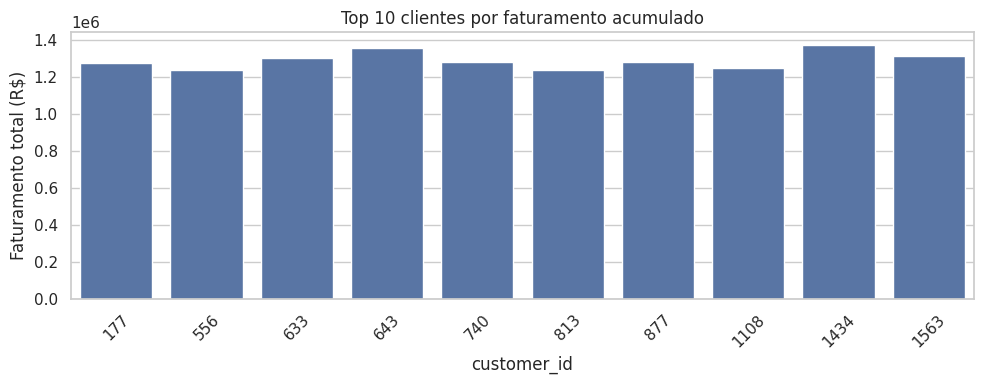

In [ ]:
plt.figure(figsize=(10,4))
sns.barplot(
    data=ranking_clientes,
    x="customer_id",
    y="faturamento_total"
)
plt.xticks(rotation=45)
plt.ylabel("Faturamento total (R$)")
plt.title("Top 10 clientes por faturamento acumulado")
plt.tight_layout()
plt.show()

**Clientes com maior faturamento acumulado**

Este gráfico mostra os 10 clientes com maior faturamento acumulado no período analisado.  
São clientes que, independentemente da frequência, geram alto volume de receita para a LH Nautical e, portanto, merecem atenção especial em termos de retenção, atendimento e oferta de serviços diferenciados.  
Cruzar essa visão com métricas de ticket médio e diversidade de categorias ajuda a identificar quais desses clientes têm comportamento mais “premium” e maior potencial de expansão.

## 4.2 Distribuição de vendas por categoria de produto

In [ ]:
oi_cat = order_items.merge(
    product_variants[["id", "product_id"]],
    left_on="product_variant_id",
    right_on="id",
    how="left"
).merge(
    products[["id", "category_id"]],
    left_on="product_id",
    right_on="id",
    how="left"
)

vendas_por_categoria = (
    oi_cat.groupby("category_id")["line_total"]
    .sum()
    .reset_index()
    .sort_values("line_total", ascending=False)
)

vendas_por_categoria.head(10)

,category_id,line_total
7,8,1.461696e+08
4,5,1.185385e+08
13,14,1.128091e+08
5,6,1.104306e+08
2,3,1.091060e+08
10,11,1.047868e+08
11,12,1.029172e+08
0,1,1.022853e+08
6,7,1.012817e+08
12,13,9.970708e+07


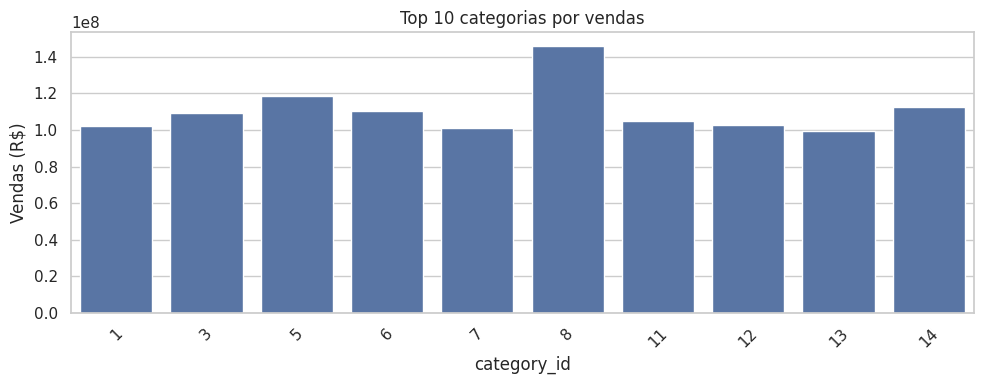

In [ ]:
plt.figure(figsize=(10,4))
sns.barplot(
    data=vendas_por_categoria.head(10),
    x="category_id",
    y="line_total"
)
plt.xticks(rotation=45)
plt.ylabel("Vendas (R$)")
plt.title("Top 10 categorias por vendas")
plt.tight_layout()
plt.show()

**Top 10 categorias por vendas**

Este gráfico apresenta as 10 categorias de produto com maior volume de vendas (em R$) no período analisado.  
As categorias no topo concentram a maior parte da receita, indicando quais linhas de produtos são mais relevantes para o negócio da LH Nautical em termos de giro e faturamento.  
Essa visão ajuda a priorizar decisões de estoque, campanhas de marketing e negociação com fornecedores: categorias com vendas muito altas podem merecer maior atenção em disponibilidade, enquanto categorias com vendas menores, mas estratégicas, podem ser avaliadas com foco em margem ou diferenciação.  
Combinar este ranking com análises de prejuízo/margem por produto e comportamento de clientes fiéis permite enxergar não só o que vende mais, mas também o que traz mais resultado para a empresa.

## 4.3 Evolução das vendas mensais

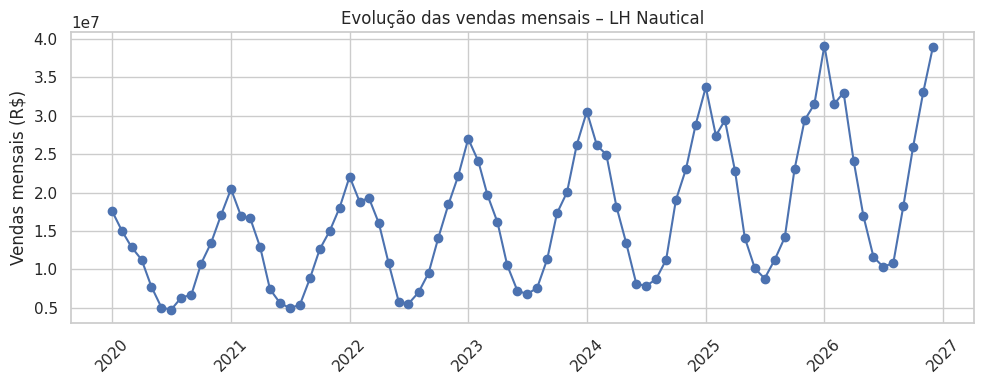

In [ ]:
orders["created_at"] = pd.to_datetime(orders["created_at"])
orders["year_month"] = orders["created_at"].dt.to_period("M")

vendas_mensais = (
    orders.groupby("year_month")["total"]
    .sum()
    .reset_index()
)

vendas_mensais["year_month_ts"] = vendas_mensais["year_month"].dt.to_timestamp()

plt.figure(figsize=(10,4))
plt.plot(vendas_mensais["year_month_ts"], vendas_mensais["total"], marker="o")
plt.xticks(rotation=45)
plt.ylabel("Vendas mensais (R$)")
plt.title("Evolução das vendas mensais – LH Nautical")
plt.tight_layout()
plt.show()

**Evolução das vendas mensais**

Este gráfico mostra a soma de vendas por mês ao longo do período de 2020 a 2026.  
É possível observar a tendência geral de crescimento/estabilização ao longo dos anos, além de eventuais picos de demanda em determinados meses (ex.: alta em períodos de verão ou promoções).  
Essa visão ajuda a entender a sazonalidade da LH Nautical e identificar meses críticos para planejamento de estoque e campanhas comerciais.

## Ranking de prejuízo aproximado por produto

In [ ]:
# Extra – Ranking de prejuízo aproximado por produto

# Juntar order_items -> product_variants -> products
oi_margem = order_items.merge(
    product_variants[["id", "product_id", "cost_price"]],
    left_on="product_variant_id",
    right_on="id",
    how="left",
    suffixes=("", "_pv")
)

oi_margem = oi_margem.merge(
    products[["id", "name"]],
    left_on="product_id",
    right_on="id",
    how="left",
    suffixes=("", "_prod")
)

# Calcular custo total e receita total por produto
oi_margem["custo_total"] = oi_margem["quantity"] * oi_margem["cost_price"]
oi_margem["receita_total"] = oi_margem["line_total"]

prejuizo_produto = (
    oi_margem.groupby(["product_id", "name"])
    .agg(
        custo_total=("custo_total", "sum"),
        receita_total=("receita_total", "sum"),
    )
)

prejuizo_produto["prejuizo_aprox"] = prejuizo_produto["custo_total"] - prejuizo_produto["receita_total"]

# Ranking dos 10 piores (maior prejuízo)
ranking_prejuizo = (
    prejuizo_produto.sort_values("prejuizo_aprox", ascending=False)
    .head(10)
    .reset_index()
)

ranking_prejuizo

,product_id,name,custo_total,receita_total,prejuizo_aprox
0,246,Motor de Popa 1365,49329.00,78433.11,-29104.11
1,412,Motor de Popa 6647,78296.07,121374.54,-43078.47
2,489,Defensa Náutica 9755,47440.55,97251.27,-49810.72
3,458,Sonar Transducer 9222,61854.24,115666.74,-53812.50
4,383,Sonar Transducer 7919,175138.05,229431.81,-54293.76
5,200,Tinta Antifouling 4777,140966.40,208627.20,-67660.80
6,210,João da Silva,133842.40,205778.70,-71936.30
7,398,Âncora Bruce 4713,202968.35,280095.53,-77127.18
8,407,Motor de Popa 3225,122018.24,200107.12,-78088.88
9,262,Hélice de Alumínio 9192,110759.46,199365.31,-88605.85


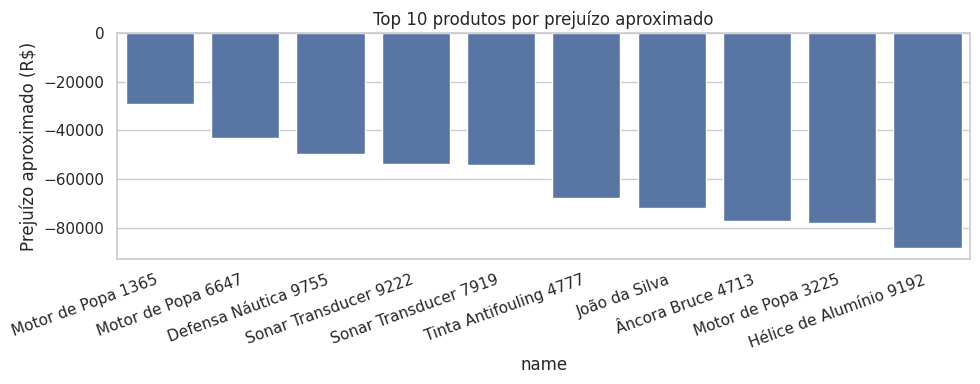

In [ ]:
ranking_prejuizo_plot = ranking_prejuizo.sort_values("prejuizo_aprox", ascending=False)

plt.figure(figsize=(10,4))
sns.barplot(
    data=ranking_prejuizo_plot,
    x="name",
    y="prejuizo_aprox"
)
plt.xticks(rotation=20, ha="right")
plt.ylabel("Prejuízo aproximado (R$)")
plt.title("Top 10 produtos por prejuízo aproximado")
plt.tight_layout()
plt.show()

**Produtos com maior prejuízo aproximado**

Este gráfico apresenta os 10 produtos com maior prejuízo aproximado, calculado como custo total menos receita total (custo > receita).  
Os itens no topo do ranking são aqueles que mais consomem margem, seja por preço de venda baixo, custo alto ou combinação de ambos.  
Esses produtos são candidatos prioritários para revisão de preço, negociação com fornecedores ou até descontinuação, dependendo da estratégia da LH Nautical.

## 5. Dimensão de calendário e vendas por dia da semana

In [ ]:
# 5. Dimensão de calendário e média de vendas por dia da semana (canal pos)

orders_pos = orders[orders["channel"] == "pos"].copy()
orders_pos["created_at"] = pd.to_datetime(orders_pos["created_at"])

# Criar coluna date como datetime (sem hora)
orders_pos["date"] = orders_pos["created_at"].dt.floor("D")  # ou .dt.normalize()

data_min = orders_pos["date"].min()
data_max = orders_pos["date"].max()

print("Período:", data_min, "até", data_max)

# Calendário diário (datetime64[ns])
calendario = pd.DataFrame(
    {"date": pd.date_range(start=data_min, end=data_max, freq="D")}
)

calendario["dia_semana_num"] = calendario["date"].dt.weekday  # 0=Segunda, 6=Domingo

dias_pt = {
    0: "Segunda-feira",
    1: "Terça-feira",
    2: "Quarta-feira",
    3: "Quinta-feira",
    4: "Sexta-feira",
    5: "Sábado",
    6: "Domingo",
}
calendario["dia_semana_pt"] = calendario["dia_semana_num"].map(dias_pt)

# Vendas diárias (garantindo date como datetime64[ns])
vendas_diarias = (
    orders_pos.groupby("date")["total"]
    .sum()
    .to_frame("valor_venda_dia")
    .reset_index()
)

# Garantir que os dois 'date' são datetime64[ns]
calendario["date"] = pd.to_datetime(calendario["date"])
vendas_diarias["date"] = pd.to_datetime(vendas_diarias["date"])

# LEFT JOIN calendário × vendas
calendario_vendas = calendario.merge(
    vendas_diarias,
    on="date",
    how="left"
)

calendario_vendas["valor_venda_dia"] = calendario_vendas["valor_venda_dia"].fillna(0)

# Média por dia da semana
media_dia_semana = (
    calendario_vendas.groupby("dia_semana_pt")["valor_venda_dia"]
    .mean()
    .reset_index()
    .sort_values("valor_venda_dia")
)

media_dia_semana

Período: 2020-01-01 00:00:00 até 2026-12-31 00:00:00


,dia_semana_pt,valor_venda_dia
2,Quinta-feira,157154.318607
0,Domingo,157616.131370
3,Segunda-feira,158241.154603
5,Sábado,164858.270082
6,Terça-feira,166118.830849
4,Sexta-feira,170193.682877
1,Quarta-feira,173605.435027


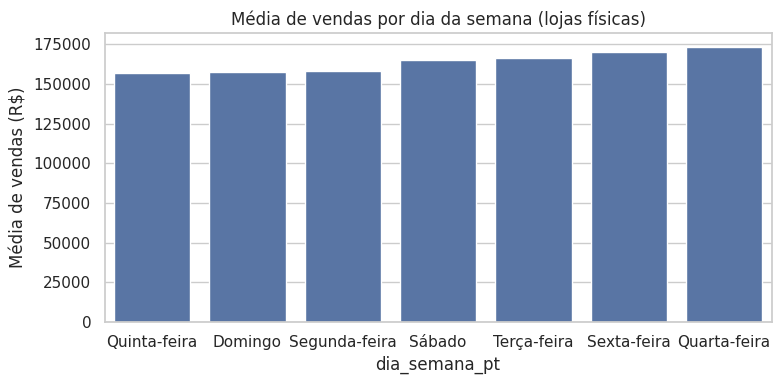

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(
    data=media_dia_semana,
    x="dia_semana_pt",
    y="valor_venda_dia",
    order=media_dia_semana["dia_semana_pt"]
)
plt.xticks(rotation=0)
plt.ylabel("Média de vendas (R$)")
plt.title("Média de vendas por dia da semana (lojas físicas)")
plt.tight_layout()
plt.show()

**Média de vendas por dia da semana (lojas físicas)**

Este gráfico apresenta a média de vendas diárias nas lojas físicas, por dia da semana, considerando **todos os dias do calendário**, inclusive dias com zero venda.  
Ao incluir dias sem registro de venda na média, evitamos inflar artificialmente dias que vendem pouco, mas têm poucas observações.  
O dia com menor média de vendas é um candidato natural para revisão de operação (redução de horário, fechamento parcial ou ações comerciais específicas), enquanto os dias com maior média indicam picos de demanda que podem exigir reforço de estoque e equipe.

## 6. Previsão de demanda – Bússola de Bordo 702

In [ ]:
# 6. Previsão de demanda – Bússola de Bordo 702

produto_alvo = products[products["name"] == "Bússola de Bordo 702"]
product_id_alvo = int(produto_alvo.iloc[0]["id"])

variantes_alvo = product_variants[product_variants["product_id"] == product_id_alvo]
variant_ids_alvo = variantes_alvo["id"].tolist()

order_items_alvo = order_items[order_items["product_variant_id"].isin(variant_ids_alvo)]

orders_subset = orders[["id", "created_at"]].rename(columns={"id": "order_id"})

df_bussola = order_items_alvo.merge(orders_subset, on="order_id", how="left")
df_bussola["created_at"] = pd.to_datetime(df_bussola["created_at"])
df_bussola["year_month"] = df_bussola["created_at"].dt.to_period("M")

mensal_bussola = (
    df_bussola.groupby("year_month")["quantity"]
    .sum()
    .to_frame("qty")
    .sort_index()
)

mensal_bussola.head()

,qty
year_month,
2020-01,22
2020-02,14
2020-03,1
2020-04,32
2020-05,5


In [ ]:
# Separar treino (até 2025-12) e teste (2026-01 a 2026-03)

mensal_df = mensal_bussola.copy()
mensal_df["year_month_ts"] = mensal_df.index.to_timestamp()

treino = mensal_df[mensal_df["year_month_ts"] <= pd.Timestamp("2025-12-31")]
teste = mensal_df[
    (mensal_df["year_month_ts"] >= pd.Timestamp("2026-01-01")) &
    (mensal_df["year_month_ts"] <= pd.Timestamp("2026-03-31"))
]

print("Período de treino (últimas linhas):")
display(treino.tail())

print("\nPeríodo de teste (jan–mar/2026):")
display(teste)

# Função para previsão com média móvel de 3 meses (sem data leakage)
def previsao_mm3(mensal_series, target_period):
    """
    mensal_series: Series indexada por Period (freq='M') com qty histórica.
    target_period: Period (ex.: Period('2026-01', 'M')).
    Retorna a média dos 3 meses anteriores ao mês alvo.
    """
    prev_periods = [
        target_period - 1,
        target_period - 2,
        target_period - 3,
    ]
    vals = []
    for p in prev_periods:
        if p in mensal_series.index:
            vals.append(mensal_series.loc[p])
    if not vals:
        # fallback: média global da série caso não haja histórico suficiente
        return float(mensal_series.mean())
    return float(np.mean(vals))

Período de treino (últimas linhas):


,qty,year_month_ts
year_month,,
2025-08,5,2025-08-01
2025-09,21,2025-09-01
2025-10,26,2025-10-01
2025-11,36,2025-11-01
2025-12,14,2025-12-01



Período de teste (jan–mar/2026):


,qty,year_month_ts
year_month,,
2026-01,69,2026-01-01
2026-02,42,2026-02-01
2026-03,45,2026-03-01


In [ ]:
# Série mensal completa para o produto
series_mensal = mensal_bussola["qty"]

# Gerar previsões para o primeiro trimestre de 2026
periods_teste = teste.index  # PeriodIndex (M) de 2026-01, 2026-02, 2026-03

previsoes = {}
for p in periods_teste:
    previsoes[p] = previsao_mm3(series_mensal, p)

previsoes_df = pd.DataFrame(
    {
        "year_month": periods_teste,
        "y_real": teste["qty"].values,
        "y_pred": [previsoes[p] for p in periods_teste],
    }
)
previsoes_df["abs_error"] = (previsoes_df["y_real"] - previsoes_df["y_pred"]).abs()

# MAE
mae = previsoes_df["abs_error"].mean()

# Soma prevista no trimestre
soma_prev_trimestre = previsoes_df["y_pred"].sum()
soma_prev_trimestre_arredondada = int(round(soma_prev_trimestre))

print("Previsões mensais (real vs previsto):")
display(previsoes_df)

print("\nMAE:", mae)
print("Soma total prevista no 1º trimestre de 2026 (arredondada):", soma_prev_trimestre_arredondada)

Previsões mensais (real vs previsto):


,year_month,y_real,y_pred,abs_error
0,2026-01,69,25.333333,43.666667
1,2026-02,42,39.666667,2.333333
2,2026-03,45,41.666667,3.333333



MAE: 16.444444444444446
Soma total prevista no 1º trimestre de 2026 (arredondada): 107


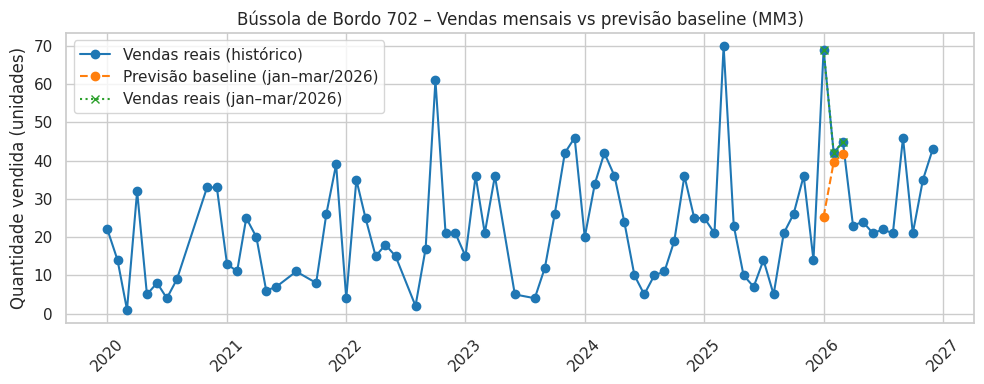

In [ ]:
# Gráfico de série mensal da Bússola de Bordo 702 com previsões para o 1º trimestre de 2026

# Converter índices Period para timestamps para plot
mensal_bussola_plot = mensal_bussola.copy()
mensal_bussola_plot["year_month_ts"] = mensal_bussola_plot.index.to_timestamp()

# Também converter year_month de previsoes_df
previsoes_plot = previsoes_df.copy()
previsoes_plot["year_month_ts"] = previsoes_plot["year_month"].dt.to_timestamp()

plt.figure(figsize=(10,4))

# Linha de vendas reais (histórico completo)
plt.plot(
    mensal_bussola_plot["year_month_ts"],
    mensal_bussola_plot["qty"],
    label="Vendas reais (histórico)",
    color="tab:blue",
    marker="o"
)

# Linha de previsões (somente meses de teste)
plt.plot(
    previsoes_plot["year_month_ts"],
    previsoes_plot["y_pred"],
    label="Previsão baseline (jan–mar/2026)",
    color="tab:orange",
    marker="o",
    linestyle="--"
)

# Destacar valores reais no período de teste
plt.plot(
    previsoes_plot["year_month_ts"],
    previsoes_plot["y_real"],
    label="Vendas reais (jan–mar/2026)",
    color="tab:green",
    marker="x",
    linestyle=":"
)

plt.xticks(rotation=45)
plt.ylabel("Quantidade vendida (unidades)")
plt.title("Bússola de Bordo 702 – Vendas mensais vs previsão baseline (MM3)")
plt.legend()
plt.tight_layout()
plt.show()

**Previsão de demanda da Bússola de Bordo 702**

O gráfico compara a série real de vendas mensais da *Bússola de Bordo 702* com as previsões do baseline de média móvel de 3 meses para o primeiro trimestre de 2026.  
Em fevereiro e março, o baseline se aproxima bem dos valores reais, enquanto em janeiro há um desvio maior (previsão subestimada em relação ao pico de demanda).  
O MAE (~16,44 unidades) mostra que o modelo é simples e explicável, mas não captura plenamente aumentos bruscos de demanda em meses fortes.  
Esse baseline funciona como referência inicial, mas pode ser aprimorado com modelos que considerem sazonalidade anual, campanhas e outras variáveis de negócio.

## 7. Sistema de recomendação – Motor de Popa 1949

In [ ]:
# 7. Sistema de recomendação – Motor de Popa 1949

orders_subset = orders[["id", "customer_id"]].rename(columns={"id": "order_id"})
oi = order_items[["order_id", "product_variant_id"]]
pv = product_variants[["id", "product_id"]].rename(columns={"id": "product_variant_id"})
prod = products[["id", "name"]].rename(columns={"id": "product_id"})

oi_orders = oi.merge(orders_subset, on="order_id", how="left")
oi_pv = oi_orders.merge(pv, on="product_variant_id", how="left")
oi_pv = oi_pv.dropna(subset=["product_id"])

oi_pv["customer_id"] = oi_pv["customer_id"].astype(int)
oi_pv["product_id"] = oi_pv["product_id"].astype(int)

cliente_produto = oi_pv[["customer_id", "product_id"]].drop_duplicates()
matriz = (
    cliente_produto.assign(valor=1)
    .pivot_table(index="customer_id", columns="product_id", values="valor", fill_value=0)
)

matriz_produtos = matriz.T
matriz_array = matriz_produtos.values
sim_matrix = cosine_similarity(matriz_array)
product_ids = matriz_produtos.index.to_list()

motor_row = prod[prod["name"] == "Motor de Popa 1949"]
motor_product_id = int(motor_row.iloc[0]["product_id"])
motor_idx = product_ids.index(motor_product_id)

motor_sim_vector = sim_matrix[motor_idx]
sim_df = pd.DataFrame({"product_id": product_ids, "similaridade": motor_sim_vector})
sim_df = sim_df[sim_df["product_id"] != motor_product_id]
top5 = sim_df.sort_values(by="similaridade", ascending=False).head(5)
top5 = top5.merge(prod, on="product_id", how="left")
top5

,product_id,similaridade,name
0,389,0.256553,Motor de Popa 5331
1,295,0.256239,Cabo Náutico 2105
2,75,0.255785,Vela Mestra 1913
3,337,0.239332,Cabo Náutico 9048
4,55,0.237744,GPS Plotter 6249


**Produtos recomendados para “Motor de Popa 1949”**

A partir da matriz Usuário × Produto e da similaridade de cosseno entre vetores de produtos, identificamos os 5 itens com padrão de compra mais parecido com o *“Motor de Popa 1949”*.  
O produto mais similar é o **“Motor de Popa 5331”**, seguido por itens como **Cabo Náutico 2105**, **Vela Mestra 1913**, **Cabo Náutico 9048** e **GPS Plotter 6249**.  
Esses resultados sugerem que clientes que compram o motor de popa frequentemente também adquirem outros motores, cabos e itens de navegação associados, o que os torna bons candidatos para uma vitrine “Quem comprou isso, também levou…”.  
Como o modelo é puramente item–item, baseado em coocorrência de compras, ele é simples de explicar e implementar, mas não leva em conta contexto de estoque, margem ou preferências individuais de cada cliente.

## 8. Ranking de prejuízo aproximado por produto

In [ ]:
# Juntar order_items -> product_variants -> products

oi_margem = order_items.merge(
    product_variants[["id", "product_id", "cost_price"]],
    left_on="product_variant_id",
    right_on="id",
    how="left",
    suffixes=("", "_pv")
)

oi_margem = oi_margem.merge(
    products[["id", "name"]],
    left_on="product_id",
    right_on="id",
    how="left",
    suffixes=("", "_prod")
)

# Calcular custo total e receita total por produto
oi_margem["custo_total"] = oi_margem["quantity"] * oi_margem["cost_price"]
oi_margem["receita_total"] = oi_margem["line_total"]

prejuizo_produto = (
    oi_margem.groupby(["product_id", "name"])
    .agg(
        custo_total=("custo_total", "sum"),
        receita_total=("receita_total", "sum"),
    )
)

prejuizo_produto["prejuizo_aprox"] = prejuizo_produto["custo_total"] - prejuizo_produto["receita_total"]

# Ranking dos 10 piores (maior prejuízo)
ranking_prejuizo = (
    prejuizo_produto.sort_values("prejuizo_aprox", ascending=False)
    .head(10)
    .reset_index()
)

ranking_prejuizo

,product_id,name,custo_total,receita_total,prejuizo_aprox
0,246,Motor de Popa 1365,49329.00,78433.11,-29104.11
1,412,Motor de Popa 6647,78296.07,121374.54,-43078.47
2,489,Defensa Náutica 9755,47440.55,97251.27,-49810.72
3,458,Sonar Transducer 9222,61854.24,115666.74,-53812.50
4,383,Sonar Transducer 7919,175138.05,229431.81,-54293.76
5,200,Tinta Antifouling 4777,140966.40,208627.20,-67660.80
6,210,João da Silva,133842.40,205778.70,-71936.30
7,398,Âncora Bruce 4713,202968.35,280095.53,-77127.18
8,407,Motor de Popa 3225,122018.24,200107.12,-78088.88
9,262,Hélice de Alumínio 9192,110759.46,199365.31,-88605.85


## 8. Conclusões e insights principais

### Principais insights

A análise abrange vendas, produtos e clientes da LH Nautical entre [período inicial] e [período final], com foco em entender padrões de demanda, desempenho por categoria e oportunidades de melhoria em estoque e pricing.

- **Dia da semana com pior média de vendas (lojas físicas):** [ex.: segunda-feira, com média de X vendas/dia].  
  Esse dia concentra menos tráfego nas lojas físicas, o que sugere oportunidade para ações promocionais ou eventos específicos (ex.: “Segunda do Marinheiro”) para aumentar conversão.

- **Produtos com maior prejuízo / risco de estoque:**  
  - Top 5 produtos com maior prejuízo acumulado: [listar nomes ou IDs dos produtos].  
  - Principais causas observadas: [ex.: alto volume de devoluções, margem negativa, baixa rotatividade com alto estoque parado].  
  - Recomendação: revisar política de preços, negociar com fornecedores ou descontinuar itens com baixa perspectiva de giro.

- **Clientes mais valiosos:** Top 10 clientes fiéis com alto ticket médio e diversidade de categorias.  
  Esses clientes são candidatos naturais para programas de fidelidade, ofertas exclusivas e testes de novos produtos, pois combinam alto valor e comportamento de compra diversificado.

- **Top categorias por vendas:** As categorias [citar as 3–5 principais, se desejar] concentram a maior parte da receita, indicando onde focar estoque, reposição e ações de marketing.  
  Categorias com vendas menores, mas estratégicas, podem ser avaliadas com foco em margem e diferenciação.

- **Previsão de demanda – Bússola de Bordo 702:**
  - MAE ≈ 16,44 unidades.
  - Soma prevista para o 1º trimestre de 2026 ≈ 107 unidades.
  - Implicação: usar essa previsão como base para planejamento de compras e estoque inicial do trimestre, mantendo uma margem de segurança para picos de demanda não capturados pelo modelo simples.

- **Recomendação para “Motor de Popa 1949”:**
  - Produto mais similar: **Motor de Popa 5331**.  
  - Demais itens: Cabo Náutico 2105, Vela Mestra 1913, Cabo Náutico 9048, GPS Plotter 6249.
  - Uso prático: aproveitar essa similaridade para estratégias de cross-sell, bundles e recomendação no site (“quem comprou o Motor 1949 também levou…”).